# Test on real-space interpolation task of Kolmogorov flow

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import json
from collections import namedtuple
from einops import rearrange
from torch_ema import ExponentialMovingAverage

from modules_irsde import get_conditional_unet
from sampling import get_sampling_func
from diffusion import get_diffusion
from corruptions import get_corrupt_sr
from datasets import get_bound_func
from utils import *

data_name = 'kol'
version = 'pretrain_ri'        # change to the version of your own run
opt_path = './__results__/' + data_name + '_' + version + '/opt.json'
with open(opt_path, 'r', encoding='utf-8') as f:
    opt = json.load(f)
OPT_class = namedtuple('OPT_class', opt.keys())
opt = OPT_class(**opt)

## Load model

In [2]:
net = get_conditional_unet(opt)
ema = ExponentialMovingAverage(net.parameters(), decay=opt.ema_rate)
checkpoint_path = opt.results_path + '/checkpoint_tunePF.pt'   # use '/checkpoint.pt' for untuned model and '/checkpoint_tunePF.pt' for finetuned model

checkpoint = torch.load(checkpoint_path, map_location="cpu")
net.load_state_dict(checkpoint['net'])
print(f"[Net] Loaded network ckpt: {checkpoint_path}!")
try:
    ema.load_state_dict(checkpoint["ema"])
    ema.to(opt.device)
    print(f"[Ema] Loaded ema ckpt: {checkpoint_path}!")
except:
    ema = None
    print('No ema found!')

# load logging of rewards...
try:
    logging = np.load(opt.results_path + '/tuneRL_logging.npy', allow_pickle=True).item()
except:
    logging = None
    print('No logging found!')

net = nn.DataParallel(net)
net.to(opt.device).eval()
diffusion = get_diffusion(opt)
def corrupt_func(x, mask_ratio=0.995, padding=None, noise=None, seed=None):
    shape = x.shape
    x_ = x.copy() if isinstance(x, np.ndarray) else x.clone()
    if padding is not None:
        bound_func = get_bound_func('periodic', num_grid=padding)
    else:
        bound_func = None
    if noise is not None:
        x_ += np.random.randn(*x_.shape)*noise if isinstance(x, np.ndarray) else torch.randn_like(x_)*noise
    x_ = x_.reshape(-1, *shape[-2:])
    x_lr = []
    x_recon = []
    for s in x_:
        mask, _ = mask_gen(s.shape, mask_ratio, seed=seed)
        if isinstance(x_, torch.Tensor):
            mask = torch.from_numpy(mask).to(x_.device)
        h = mask*s
        if bound_func is not None:
            h = bound_func(h)
            mask = bound_func(mask)
        x_lr.append(h)
        x_recon.append(voronoi_interp(h, mask))
    stack_fn = np.stack if isinstance(x_, np.ndarray) else torch.stack
    return rearrange(stack_fn(x_lr), '(b c) h w -> b c h w', b=shape[0]), rearrange(stack_fn(x_recon), '(b c) h w -> b c h w', b=shape[0])
mean, std = np.load(opt.results_path + '/mean_std.npy')
scalar = lambda x: (x-mean)/std
scalar_inv = lambda x: x*std+mean

[Net] Loaded network ckpt: ./__results__/kol_pretrain_ri/checkpoint_tunePF.pt!
No ema found!
No logging found!


## Load data

In [3]:
data_raw_high = np.load("/media/group3/lzy/Data/kol/kf_2d_re1000_256_40seed_bthwc.npy")
x_test_high = scalar(data_raw_high)

t_start = 200
ns_real = 10
samples_high = []
for i in range(ns_real):
    samples_high.append(x_test_high[-4:-3, t_start+i*3:t_start+i*3+opt.num_frames, :, :, 0])
samples_high = np.concatenate(samples_high)
# samples_high = bound_func(samples_high)
print(samples_high.shape)

(10, 3, 256, 256)


## Sampling

In [4]:
nfe = 10
log_count = 1
mask_ratio = 0.99
padding = 16
x1_lr, x1 = corrupt_func(samples_high, mask_ratio=mask_ratio, padding=padding, noise=0.05)
x1_lr = torch.from_numpy(x1_lr).float()
x1 = torch.from_numpy(x1).float()
cond = x1.clone()
# x1 = x1 + torch.randn_like(x1)*0.01
sampling_func = get_sampling_func(net, ema, num_scales=opt.num_scales, nfe=nfe, diffusion=diffusion, log_count=log_count, device=opt.device, ot_ode=True, es=True)
with torch.no_grad():
    xs, x0s = sampling_func(x1, cond)
print(xs.shape, x0s.shape)
xs = xs[..., padding:-padding, padding:-padding]
x0s = x0s[..., padding:-padding, padding:-padding]
x1 = x1[..., padding:-padding, padding:-padding]
torch.cuda.empty_cache()

DDPM sampling: 100%|██████████| 10/10 [00:04<00:00,  2.27it/s]

torch.Size([10, 1, 3, 288, 288]) torch.Size([10, 1, 3, 288, 288])


## Visualization

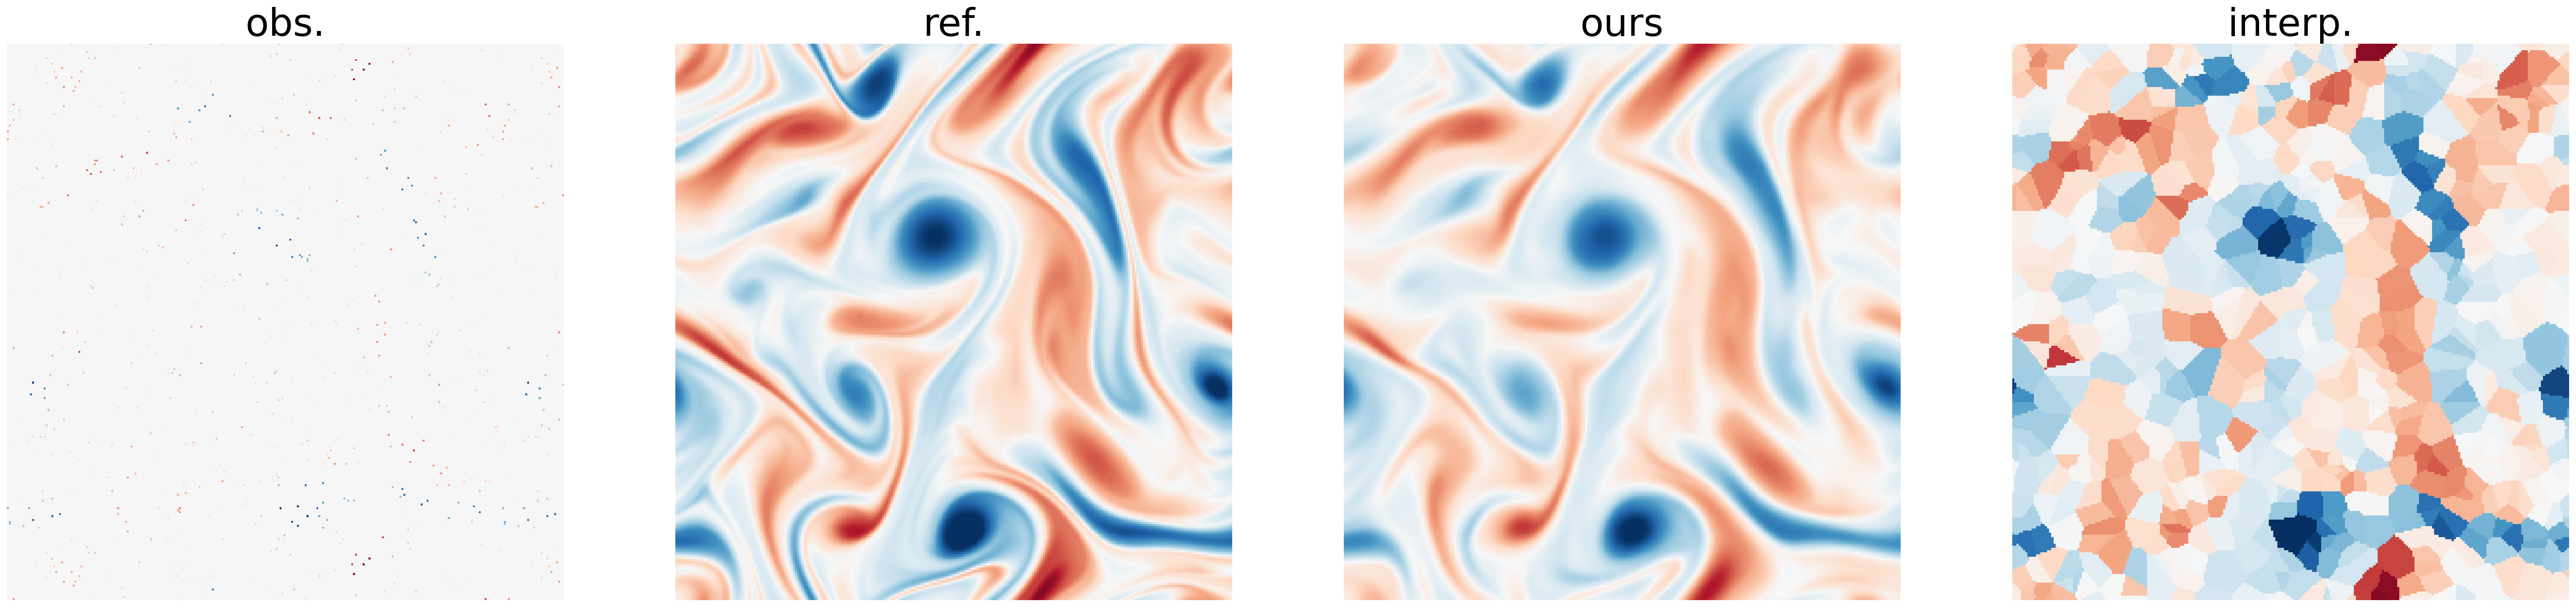

nRMSE for PalSB:  0.24402594839275965
nRMSE for interp.:  0.5844939990924813


In [7]:
import matplotlib.pyplot as plt
i_t = -1
i_c = 1
i_f = -1
x_plots = [x1_lr[i_t, i_c], samples_high[i_t, i_c], x0s[i_t, i_f, i_c], x1[i_t, i_c].detach().cpu()]
titles = ['obs.', 'ref.', 'ours', 'interp.']
fig, axes = plt.subplots(1, 4, figsize=(48, 12), dpi=200)
for i in range(len(x_plots)):
    axes[i].pcolormesh(x_plots[i], cmap='RdBu_r', vmin=-3, vmax=3)
    axes[i].set_aspect(1)
    axes[i].set_title(titles[i], fontsize=40)
    axes[i].axis('off')
plt.show()
print('nRMSE for PalSB: ', cal_rmse(samples_high, x0s[:, i_f].numpy(), normalize=True).mean())     
print('nRMSE for interp.: ', cal_rmse(samples_high, x1.detach().cpu().numpy(), normalize=True).mean())

## Equation residuals

In [9]:
def voriticity_residual(w, re=1000.0, dt=1/32):
    # w [b t h w]
    batchsize = w.size(0)
    w = w.clone()
    w.requires_grad_(True)
    nx = w.size(2)
    ny = w.size(3)
    device = w.device

    w_h = torch.fft.fft2(w[:, 1:-1], dim=[2, 3])
    # Wavenumbers in y-direction
    k_max = nx//2
    N = nx
    k_x = torch.cat((torch.arange(start=0, end=k_max, step=1, device=device),
                     torch.arange(start=-k_max, end=0, step=1, device=device)), 0).\
        reshape(N, 1).repeat(1, N).reshape(1,1,N,N)
    k_y = torch.cat((torch.arange(start=0, end=k_max, step=1, device=device),
                     torch.arange(start=-k_max, end=0, step=1, device=device)), 0).\
        reshape(1, N).repeat(N, 1).reshape(1,1,N,N)
    # Negative Laplacian in Fourier space
    lap = (k_x ** 2 + k_y ** 2)
    lap[..., 0, 0] = 1.0
    psi_h = w_h / lap

    u_h = 1j * k_y * psi_h
    v_h = -1j * k_x * psi_h
    wx_h = 1j * k_x * w_h
    wy_h = 1j * k_y * w_h
    wlap_h = -lap * w_h

    u = torch.fft.irfft2(u_h[..., :, :k_max + 1], dim=[2, 3])
    v = torch.fft.irfft2(v_h[..., :, :k_max + 1], dim=[2, 3])
    wx = torch.fft.irfft2(wx_h[..., :, :k_max + 1], dim=[2, 3])
    wy = torch.fft.irfft2(wy_h[..., :, :k_max + 1], dim=[2, 3])
    wlap = torch.fft.irfft2(wlap_h[..., :, :k_max + 1], dim=[2, 3])
    advection = u*wx + v*wy

    wt = (w[:, 2:, :, :] - w[:, :-2, :, :]) / (2 * dt)

    # establish forcing term
    x = torch.linspace(0, 2*np.pi, nx + 1, device=device)
    x = x[0:-1]
    X, Y = torch.meshgrid(x, x)
    f = -4*torch.cos(4*Y)

    residual = wt + (advection - (1.0 / re) * wlap + 0.1*w[:, 1:-1]) - f
    residual_loss = (residual**2).mean()
    dw = torch.autograd.grad(residual_loss, w)[0]
    return dw, residual, residual_loss

dw, res, loss_eq = voriticity_residual(torch.from_numpy(scalar_inv(samples_high)), re=1000, dt=1/32)
dw_, res_, loss_eq_ = voriticity_residual(scalar_inv(x0s[:, -1]), re=1000, dt=1/32)
dw_interp, res_interp, loss_eq_interp = voriticity_residual(scalar_inv(x1), re=1000, dt=1/32)
print('nER for PalSB: ', loss_eq_/(scalar_inv(samples_high)**2).mean().item())
print('nER for interp.: ', loss_eq_interp/(scalar_inv(samples_high)**2).mean().item())

nER for PalSB:  tensor(0.7919, grad_fn=<DivBackward0>)
nER for interp.:  tensor(674.3710, grad_fn=<DivBackward0>)


# Full Test on all test data

In [10]:
load_exist = False
data_kw = 'x1'
data_kw_lr = 'x1_lr'
info_kw = 'info'
padding = 16

data_test = []
for traj in x_test_high[-4:]:
    for i in range(len(traj)-opt.num_frames+1):
        h = traj[i:i+opt.num_frames]
        h = rearrange(h, 't h w c -> (t c) h w')
        data_test.append(h)
data_test = np.stack(data_test)
print(data_test.shape)

if load_exist:
    data = np.load(opt.results_path + '/corrupted_samples_n000_m99.npz')
    sampled_x1, sampled_x1_lr = scalar(data[data_kw]), scalar(data[data_kw_lr])
    bound_fn = get_bound_func('periodic', num_grid=padding)
    sampled_x1 = bound_fn(sampled_x1)
    sampled_x1_lr = bound_fn(sampled_x1_lr)
    noise_level, mask_ratio = data[info_kw]
    print(f'noise_level: {noise_level}\tmask_ratio: {mask_ratio}')
else:
    print(x_test_high.shape)
    noise_level = 0.05
    mask_ratio = 0.99
    sampled_x1_lr, sampled_x1 = corrupt_func(data_test, mask_ratio=mask_ratio, padding=padding, noise=noise_level)      # , seed=42
dataset = torch.utils.data.TensorDataset(torch.from_numpy(sampled_x1))
dataloader = torch.utils.data.DataLoader(dataset, batch_size=36, shuffle=False)

(1272, 3, 256, 256)
(40, 320, 256, 256, 1)


## Sampling

In [11]:
from tqdm import tqdm
net.eval()
nfe = 10
log_count = 10
sampling_func = get_sampling_func(net, ema, num_scales=opt.num_scales, nfe=nfe, diffusion=diffusion, log_count=log_count, device=opt.device)

sampled_x0 = []
with torch.no_grad():
    for i, (x1,) in tqdm(enumerate(dataloader), total=len(dataloader)):
        cond = x1.clone()
        # x1 = x1 + torch.randn_like(x1)*0.01
        xs, x0s = sampling_func(x1, cond)
        xs = xs[..., padding:-padding, padding:-padding]
        x0s = x0s[..., padding:-padding, padding:-padding]
        sampled_x0.append(x0s[:, -1])
sampled_x0 = torch.cat(sampled_x0)
sampled_x1 = sampled_x1[..., padding:-padding, padding:-padding]
sampled_x1_lr = sampled_x1_lr[..., padding:-padding, padding:-padding]
print(sampled_x0.shape, sampled_x1.shape, sampled_x1_lr.shape)
torch.cuda.empty_cache()

100%|██████████| 36/36 [04:18<00:00,  7.19s/it]


torch.Size([1272, 3, 256, 256]) (1272, 3, 256, 256) (1272, 3, 256, 256)


## nRMSE & nER

In [12]:
print('nRMSE for PalSB: ', cal_rmse(data_test, sampled_x0.numpy(), normalize=True).mean())     # (abs(samples_high-x0s[:, i_f].numpy())).mean()
print('nRMSE for interp.: ', cal_rmse(data_test, sampled_x1, normalize=True).mean())

dw, res, loss_eq = voriticity_residual(torch.from_numpy(scalar_inv(data_test)), re=1000, dt=1/32)
dw_, res_, loss_eq_ = voriticity_residual(scalar_inv(sampled_x0), re=1000, dt=1/32)
dw_interp, res_interp, loss_eq_interp = voriticity_residual(torch.from_numpy(scalar_inv(sampled_x1)), re=1000, dt=1/32)
print('nER for PalSB: ', loss_eq_/(scalar_inv(data_test)**2).mean().item())
print('nER for interp.: ', loss_eq_interp/(scalar_inv(data_test)**2).mean().item())

nRMSE for PalSB:  0.24793098795361865
nRMSE for interp.:  0.584986054535037
nER for PalSB:  tensor(0.7063, grad_fn=<DivBackward0>)
nER for interp.:  tensor(628.9326, grad_fn=<DivBackward0>)


## Statistics of the generated fields

/home/lzy/anaconda3/envs/palsb/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/lzy/anaconda3/envs/palsb/lib/python3.9/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


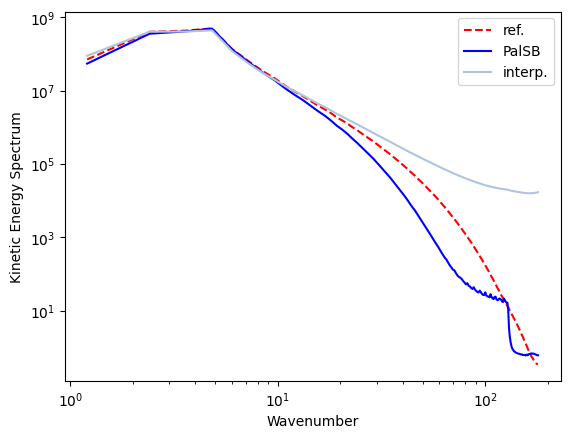

In [13]:
vor_kes = [scalar_inv(rearrange(v, 't c h w -> (t c) h w')) for v in [sampled_x0.numpy(), sampled_x1, data_test]]

dx = 2 * np.pi / 256
dy = 2 * np.pi / 256
num_bins = 150
k, _ = kes_from_vorticity(samples_high[0, 0], dx=dx, dy=dy, num_bins=num_bins)

start = 0
end = len(vor_kes[0])

[E_mean_pred0, E_mean_pred1, E_mean_ref], _ = kes_plot(vor_kes,
                                        dx=dx, dy=dy, start=start, end=end, is_plot=False, num_bins=num_bins)
fig1, ax1 = plt.subplots()
ax1.loglog(k, E_mean_ref, label=f'ref.', ls='--', color='r')
ax1.loglog(k, E_mean_pred0, label=f'PalSB', color='b')
ax1.loglog(k, E_mean_pred1, label=f'interp.', color='lightsteelblue')
# ax1.loglog(k, E_mean_1, label='without para')
plt.xlabel('Wavenumber')
plt.ylabel('Kinetic Energy Spectrum')
plt.legend()
plt.show()